# Confronto parametrizzazioni fondo gamma LNGS

Confronto tra due parametrizzazioni del fondo gamma ambientale a LNGS:

- **(A) la nostra** — spettro **continuo** da misura NaI Hall A (Bellini 2013, arXiv:1101.5298), usata in `gun_gammas_background.mac`. Include la risposta del rivelatore NaI.
- **(B) colleghi CUPID** — lista di **righe gamma discrete** (spettro di emissione "vero"), file `histo_environmental_gamma_CUPID_python_extract_true_spectrum.txt`.

Entrambe normalizzate a integrale unitario → confronto di forma + quantificazione.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

HERE = "/Users/benussi/Testbeam2026_WC_unified/Analysis_script_background"
MAC  = "/Users/benussi/Testbeam2026_WC_unified/gun_gammas_background.mac"
COLL = os.path.join(HERE, "histo_environmental_gamma_CUPID_python_extract_true_spectrum.txt")
OUT  = os.path.join(HERE, "output_final")
os.makedirs(OUT, exist_ok=True)

In [2]:
# (B) colleghi: righe discrete (E keV, intensita')
Eb, Ib = [], []
with open(COLL) as f:
    for ln in f:
        p = ln.split()
        if len(p) >= 2:
            try:
                Eb.append(float(p[0])); Ib.append(float(p[1]))
            except ValueError:
                pass
Eb = np.array(Eb); Ib = np.array(Ib)          # keV, conteggi
Ib_n = Ib / Ib.sum()                          # frazione per riga

# (A) nostra: punti continui dal .mac (E MeV -> keV, intensita' rel.)
Ea, Ia = [], []
with open(MAC) as f:
    for ln in f:
        if "/gps/hist/point" in ln:
            p = ln.split()
            try:
                Ea.append(float(p[1])*1000.0); Ia.append(float(p[2]))
            except (ValueError, IndexError):
                pass
Ea = np.array(Ea); Ia = np.array(Ia)          # keV, dN/dE (rel.)
def A_dNdE(E): return np.interp(E, Ea, Ia, left=0., right=0.)

print(f"colleghi: {len(Eb)} righe, {Eb.min():.0f}-{Eb.max():.0f} keV")
print(f"nostra:   {len(Ea)} punti, {Ea.min():.0f}-{Ea.max():.0f} keV")

colleghi: 210 righe, 19-3399 keV
nostra:   42 punti, 50-2650 keV


In [3]:
# binning comune per confronto quantitativo
BW = 50.0
edges = np.arange(0, 3450+BW, BW); cen = 0.5*(edges[:-1]+edges[1:])
hb,_ = np.histogram(Eb, bins=edges, weights=Ib); hb = hb/hb.sum()
ha = np.array([np.trapezoid(A_dNdE(np.linspace(e0,e1,20)), np.linspace(e0,e1,20))
               for e0,e1 in zip(edges[:-1],edges[1:])]); ha = ha/ha.sum()

def band_frac(h, lo, hi): return h[(cen>=lo)&(cen<hi)].sum()
def mean_E(h): return (cen*h).sum()/h.sum()

print("="*66)
print("CONFRONTO PARAMETRIZZAZIONI FONDO GAMMA LNGS (forma normalizzata)")
print("="*66)
print(f"{'':24} | {'nostra (NaI cont.)':>18} | {'colleghi (righe)':>17}")
print("-"*66)
print(f"{'energia media <E>':24} | {mean_E(ha):>15.0f} keV | {mean_E(hb):>14.0f} keV")
for lo,hi in [(0,500),(500,1500),(1500,2700),(2700,3450)]:
    print(f"{'frazione '+f'{lo}-{hi} keV':24} | {100*band_frac(ha,lo,hi):>16.1f}% | {100*band_frac(hb,lo,hi):>15.1f}%")
print("-"*66)
print("Righe dominanti file colleghi (top 6):")
for i in np.argsort(-Ib)[:6]:
    print(f"   {Eb[i]:>8.1f} keV   ({100*Ib_n[i]:.1f}% del totale)")
print("-"*66)
fa=band_frac(ha,2000,3450); fb=band_frac(hb,2000,3450)
print(f"Frazione gamma > 2 MeV:  nostra {100*fa:.2f}%   colleghi {100*fb:.2f}%   (rapporto {fb/fa:.1f}x)")
# banda rilevante per il WC (Cherenkov): > 300 keV
fa3=band_frac(ha,300,3450); fb3=band_frac(hb,300,3450)
print(f"Frazione gamma > 300 keV (rilevante WC):  nostra {100*fa3:.1f}%   colleghi {100*fb3:.1f}%")

CONFRONTO PARAMETRIZZAZIONI FONDO GAMMA LNGS (forma normalizzata)
                         | nostra (NaI cont.) |  colleghi (righe)
------------------------------------------------------------------
energia media <E>        |             285 keV |            419 keV
frazione 0-500 keV       |             88.9% |            72.2%
frazione 500-1500 keV    |              7.7% |            23.2%
frazione 1500-2700 keV   |              3.4% |             4.6%
frazione 2700-3450 keV   |              0.0% |             0.0%
------------------------------------------------------------------
Righe dominanti file colleghi (top 6):
       19.0 keV   (16.7% del totale)
       99.1 keV   (9.6% del totale)
      149.7 keV   (5.9% del totale)
       30.3 keV   (4.9% del totale)
     1459.0 keV   (4.3% del totale)
       40.1 keV   (3.9% del totale)
------------------------------------------------------------------
Frazione gamma > 2 MeV:  nostra 1.18%   colleghi 1.80%   (rapporto 1.5x)
Frazione gamma

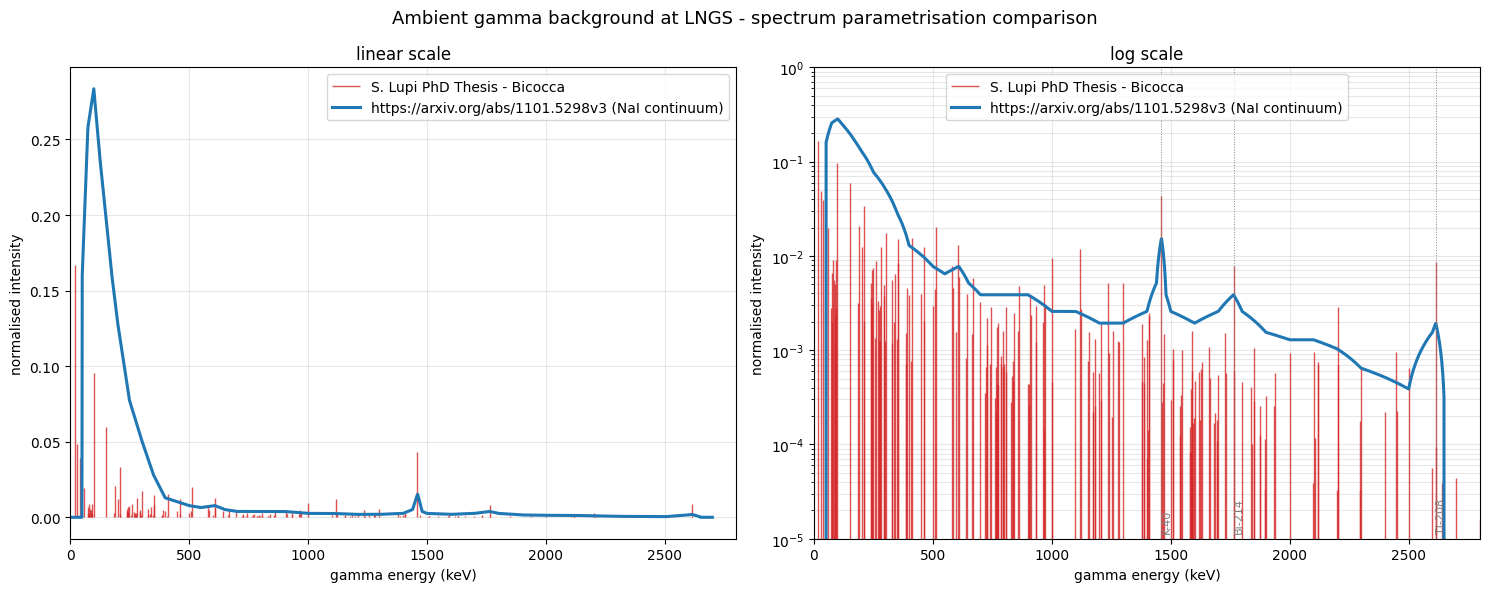

In [5]:
# plot
fig,(ax_lin,ax_log)=plt.subplots(1,2,figsize=(15,6))
fig.suptitle("Ambient gamma background at LNGS - spectrum parametrisation comparison", fontsize=13)
for ax,logy in ((ax_lin,False),(ax_log,True)):
    ax.vlines(Eb, 0, Ib_n, color="#d62728", lw=1.0, alpha=0.8, label="S. Lupi PhD Thesis - Bicocca")
    Efine=np.linspace(0,2700,2000); Afine=A_dNdE(Efine)
    Afine=Afine/np.trapezoid(Afine,Efine)*BW
    ax.plot(Efine, Afine, color="#1f77b4", lw=2.2, label="https://arxiv.org/abs/1101.5298v3 (NaI continuum)")
    ax.set_xlabel("gamma energy (keV)"); ax.set_ylabel("normalised intensity")
    ax.set_xlim(0,2800); ax.grid(True,alpha=0.3,which="both"); ax.legend(fontsize=10)
    if logy: ax.set_yscale("log"); ax.set_ylim(1e-5,1); ax.set_title("log scale")
    else: ax.set_title("linear scale")
for E,lab in [(1461,"K-40"),(1764,"Bi-214"),(2615,"Tl-208")]:
    ax_log.axvline(E,color="gray",lw=0.7,ls=":"); ax_log.text(E,1.2e-5,lab,fontsize=8,rotation=90,color="gray")
plt.tight_layout()
fig.savefig(os.path.join(OUT,"gamma_spectra_comparison.pdf"),bbox_inches="tight")
plt.show()